In [3]:
 import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
  
conn = sqlite3.connect("enterprise_database.db")

In [4]:
# Use ROW_NUMBER() window function to get the most recent record per user
query = """
WITH latest_users AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)
SELECT *
FROM latest_users
WHERE rn = 1
AND status = 'Active';
"""

df_active_users = pd.read_sql_query(query, conn)
print(df_active_users.shape)
df_active_users.head()

(14183, 5)


,user_id,name,status,updated_at,rn
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00,1
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00,1
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00,1
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00,1
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00,1


In [5]:
# phase.2 Load raw server logs
df_logs = pd.read_csv(
    "server_logs.txt",
    header=None,
    names=["raw_log"],
    encoding="utf-8"
)

# Remove header row if present
df_logs = df_logs[df_logs["raw_log"] != "Raw_Server_Log"]

# Remove ERROR rows
df_logs_clean = df_logs[
    ~df_logs["raw_log"].str.contains("ERROR", case=False, na=False)
].copy()

print("Original Logs:", df_logs.shape)
print("After Removing ERROR:", df_logs_clean.shape)

Original Logs: (100000, 1)
After Removing ERROR: (94902, 1)


In [6]:

# Extract Date, User ID, Product ID, Euro Value via Regex
# VECTORIZED: str.extract() applies the regex across all 100,000 rows simultaneously.
# No for loops or iterrows() are used anywhere in this pipeline — required for performance.
extracted_data = df_logs_clean["raw_log"].str.extract(
    r"\[(?P<Date>\d{4}-\d{2}-\d{2}) .*?"
    r'"u":"(?P<User_ID>U-\d+)".*?'
    r'"item_code":"(?P<Product_ID>PRD-\d+)".*?'
    r'"eur_val":(?P<Euro_Value>\d+(?:\.\d+)?)'
)

# Convert data types
extracted_data["Date"] = pd.to_datetime(extracted_data["Date"])
extracted_data["Euro_Value"] = extracted_data["Euro_Value"].astype(float)

print("Extracted Data:", extracted_data.shape)
print(extracted_data.isnull().sum())
extracted_data.head()

Extracted Data: (94902, 4)
Date          0
User_ID       0
Product_ID    0
Euro_Value    0
dtype: int64


,Date,User_ID,Product_ID,Euro_Value
1,2023-03-15,U-19484,PRD-874,3404.44
3,2023-05-09,U-18932,PRD-905,3406.21
4,2023-10-21,U-15882,PRD-284,164.08
5,2023-01-10,U-22781,PRD-665,26.80
6,2023-05-23,U-13348,PRD-589,4964.77


In [7]:
# PHASE 3 Load and clean exchange rates
rates = pd.read_csv("daily_exchange_rates.csv")
rates.columns = rates.columns.str.strip()
rates = rates.rename(columns={
    rates.columns[0]: "Date",
    rates.columns[1]: "Exchange_Rate"
})
rates["Date"] = pd.to_datetime(rates["Date"])
rates = rates.sort_values("Date")

# Forward-fill weekend gaps (markets closed Sat/Sun)
rates["Exchange_Rate"] = rates["Exchange_Rate"].ffill()

print("Missing exchange rates after ffill:", rates["Exchange_Rate"].isnull().sum())
rates.head()

Missing exchange rates after ffill: 0


,Date,Exchange_Rate
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292


In [8]:
# Merge transactions with exchange rates (left join preserves all transactions)
df_reconciled = pd.merge(extracted_data, rates, on="Date", how="left")

# Calculate USD revenue
df_reconciled["USD_Revenue"] = (df_reconciled["Euro_Value"] * df_reconciled["Exchange_Rate"]).round(2)
df_reconciled["Exchange_Rate"] = df_reconciled["Exchange_Rate"].round(3)

print("Null Exchange Rates:", df_reconciled["Exchange_Rate"].isnull().sum())
df_reconciled.head()

Null Exchange Rates: 0


,Date,User_ID,Product_ID,Euro_Value,Exchange_Rate,USD_Revenue
0,2023-03-15,U-19484,PRD-874,3404.44,1.178,4011.22
1,2023-05-09,U-18932,PRD-905,3406.21,1.105,3763.80
2,2023-10-21,U-15882,PRD-284,164.08,1.075,176.44
3,2023-01-10,U-22781,PRD-665,26.80,1.127,30.21
4,2023-05-23,U-13348,PRD-589,4964.77,1.020,5062.21


In [9]:
# Align user ID types, then inner join to keep only active users
df_active_users["user_id"] = df_active_users["user_id"].astype(str)
df_reconciled["User_ID"] = df_reconciled["User_ID"].astype(str)

df_final = pd.merge(
    df_reconciled,
    df_active_users,
    left_on="User_ID",
    right_on="user_id",
    how="inner"
)

# Clean up duplicate/helper columns
df_final = df_final.drop(columns=["user_id", "rn"])
df_final["updated_at"] = pd.to_datetime(df_final["updated_at"]).dt.date

print("Extracted Transactions:", extracted_data.shape)
print("After Exchange Rate Merge:", df_reconciled.shape)
print("Final Active User Transactions:", df_final.shape)
print(df_final.isnull().sum())
df_final.head()

Extracted Transactions: (94902, 4)
After Exchange Rate Merge: (94902, 6)
Final Active User Transactions: (53899, 9)
Date             0
User_ID          0
Product_ID       0
Euro_Value       0
Exchange_Rate    0
USD_Revenue      0
name             0
status           0
updated_at       0
dtype: int64


,Date,User_ID,Product_ID,Euro_Value,Exchange_Rate,USD_Revenue,name,status,updated_at
0,2023-03-15,U-19484,PRD-874,3404.44,1.178,4011.22,User_U-19484,Active,2023-01-11
1,2023-10-21,U-15882,PRD-284,164.08,1.075,176.44,User_U-15882,Active,2023-01-16
2,2023-01-10,U-22781,PRD-665,26.80,1.127,30.21,User_U-22781,Active,2023-01-07
3,2023-10-20,U-22062,PRD-363,48.63,1.075,52.29,User_U-22062,Active,2023-01-05
4,2023-12-02,U-22146,PRD-223,960.60,1.066,1024.14,User_U-22146,Active,2023-01-18


In [10]:
df_final.to_csv("final_financial_reconciled_data.csv", index=False)

In [11]:
# Summary KPIs
total_revenue = round(df_final["USD_Revenue"].sum(), 2)
total_customers = df_final["User_ID"].nunique()
total_transactions = len(df_final)

print("Total Revenue:      $", total_revenue)
print("Total Customers:    ", total_customers)
print("Total Transactions: ", total_transactions)

Total Revenue:      $ 148274623.47
Total Customers:     13888
Total Transactions:  53899


In [12]:
#PHASE 4 Aggregate: Monthly revenue & Top 5 customers
df_final["Month"] = df_final["Date"].dt.to_period("M").astype(str)

monthly_revenue = (
    df_final.groupby("Month")["USD_Revenue"]
    .sum()
    .reset_index()
)

top_5_customers = (
    df_final.groupby("User_ID")["USD_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

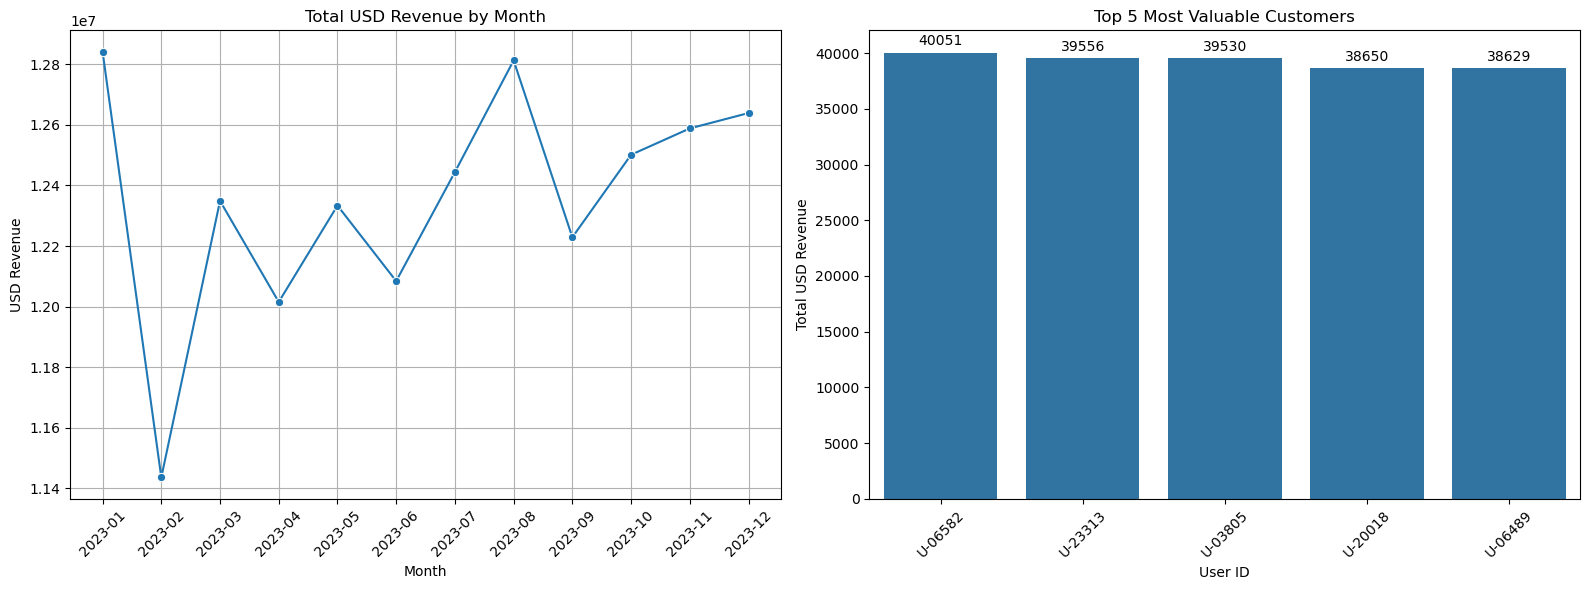

In [13]:
# CFO Dashboard: 2-panel chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Revenue by Month
sns.lineplot(data=monthly_revenue, x="Month", y="USD_Revenue", marker="o", ax=axes[0])
axes[0].set_title("Total USD Revenue by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("USD Revenue")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True)

# Chart 2: Top 5 Customers
ax = sns.barplot(
    data=top_5_customers,
    x="User_ID",
    y="USD_Revenue",
    ax=axes[1]
)

axes[1].set_title("Top 5 Most Valuable Customers")
axes[1].set_xlabel("User ID")
axes[1].set_ylabel("Total USD Revenue")
axes[1].tick_params(axis="x", rotation=45)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',      # no decimals
        padding=3
    )

plt.tight_layout()
plt.savefig("cfo_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
df_final.head()

,Date,User_ID,Product_ID,Euro_Value,Exchange_Rate,USD_Revenue,name,status,updated_at,Month
0,2023-03-15,U-19484,PRD-874,3404.44,1.178,4011.22,User_U-19484,Active,2023-01-11,2023-03
1,2023-10-21,U-15882,PRD-284,164.08,1.075,176.44,User_U-15882,Active,2023-01-16,2023-10
2,2023-01-10,U-22781,PRD-665,26.80,1.127,30.21,User_U-22781,Active,2023-01-07,2023-01
3,2023-10-20,U-22062,PRD-363,48.63,1.075,52.29,User_U-22062,Active,2023-01-05,2023-10
4,2023-12-02,U-22146,PRD-223,960.60,1.066,1024.14,User_U-22146,Active,2023-01-18,2023-12


In [16]:
df_final = df_final.drop(columns=['Month'])

df_final.to_csv(
    'final_reconciled_data.csv',
    index=False
)

In [15]:
# Select and rename columns for clean Power BI ingestion
power_bi_df = df_final[[
    "Date", "User_ID", "Product_ID",
    "Euro_Value", "Exchange_Rate", "USD_Revenue",
    "status", "updated_at"
]].copy()

# Export — filename required by project brief
power_bi_df.to_csv("power_bi_ready_dataset.csv", index=False)

print("BI Handoff complete!")
print("File: power_bi_ready_dataset.csv")
print("Rows exported:", len(power_bi_df))
print("Columns:", list(power_bi_df.columns))
power_bi_df.head()

BI Handoff complete!
File: power_bi_ready_dataset.csv
Rows exported: 53899
Columns: ['Date', 'User_ID', 'Product_ID', 'Euro_Value', 'Exchange_Rate', 'USD_Revenue', 'status', 'updated_at']


,Date,User_ID,Product_ID,Euro_Value,Exchange_Rate,USD_Revenue,status,updated_at
0,2023-03-15,U-19484,PRD-874,3404.44,1.178,4011.22,Active,2023-01-11
1,2023-10-21,U-15882,PRD-284,164.08,1.075,176.44,Active,2023-01-16
2,2023-01-10,U-22781,PRD-665,26.80,1.127,30.21,Active,2023-01-07
3,2023-10-20,U-22062,PRD-363,48.63,1.075,52.29,Active,2023-01-05
4,2023-12-02,U-22146,PRD-223,960.60,1.066,1024.14,Active,2023-01-18
